# **Students' Mental Health Score Prediction Using Machine Learning**

>This project aims to predict students' mental health scores based on social media usage, demographic information, academic factors, and other relevant features using machine learning regression models.

# 1-Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (r2_score,
                             mean_absolute_error,
                             mean_squared_error)

# 2-Load Dataset

In [2]:
df = pd.read_csv("Student Social Media And Mental Health Impact.csv")

# 3. Exploratory Data Overview

>Before performing data cleaning and machine learning, we explore the dataset to understand its structure, features, data types, and statistical properties.

## *First Five Records*

In [3]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


## *Last Five Records*

In [4]:
df.tail()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7
4999,19,Male,China,Undergraduate,WeChat,Entertainment,5.4,177,1.2,1.5,6.3,High,6.1


## Dataset Information

>This section provides information about the dataset, including column names, data types, non-null values, and memory usage.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 736.5 KB


## Statistical Summary

>The statistical summary provides important descriptive statistics for numerical features, including the mean, standard deviation, minimum, maximum, and quartile values.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,20.82180,1.736620,18.0,19.0,21.0,22.0,24.0
Avg_Daily_Usage_Hours,5000.0,5.07846,1.653913,1.0,3.8,5.0,6.3,8.8
Daily_Unlocks,5000.0,171.45260,42.858254,62.0,140.0,171.0,204.0,273.0
Study_Hours,5000.0,3.00842,1.637018,0.3,1.5,2.8,4.2,8.3
Physical_Activity_Hours,5000.0,1.75100,0.668398,-0.4,1.3,1.7,2.2,4.1
Sleep_Hours_Per_Night,5000.0,6.63458,1.221391,3.6,5.6,6.6,7.5,9.9
Mental_Health_Score,5000.0,6.23098,1.278701,3.6,5.1,6.1,7.1,9.4


# 4. Data Cleaning

>Data cleaning is performed to identify and handle missing values and duplicate records before proceeding with exploratory data analysis and machine learning.

In [7]:
df.isna().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

>The dataset was checked for missing values. No missing values were found in the dataset.

In [8]:
df.duplicated().sum()

np.int64(2)

In [9]:
df = df.drop_duplicates()

> The dataset contained two duplicate records, which were removed.

# 5. Exploratory Data Analysis (EDA)

>Exploratory Data Analysis is performed to understand the distribution of variables, relationships between features, and patterns that may influence students' mental health scores.

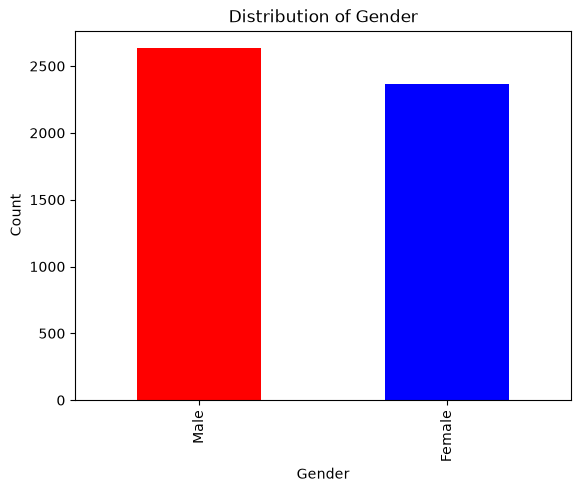

In [10]:
df.Gender.value_counts().plot(kind='bar',color=['red','blue']);
plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

### Academic Level Distribution

>The following visualization shows the distribution of students across different academic levels.

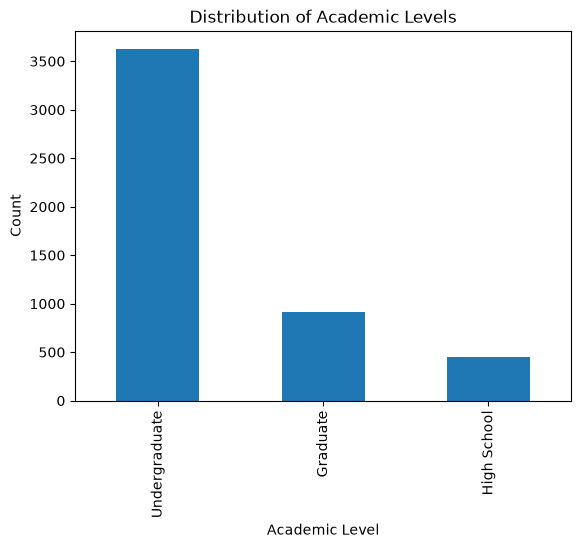

In [11]:
#df.Academic_Level.value_counts().plot(kind='bar',color=['red','blue','green']);
df['Academic_Level'].value_counts().plot(kind='bar')
plt.title("Distribution of Academic Levels")
plt.xlabel("Academic Level")
plt.ylabel("Count")
plt.show()

### Most Used Social Media Platform

>This visualization shows which social media platforms are most commonly used by students in the dataset.

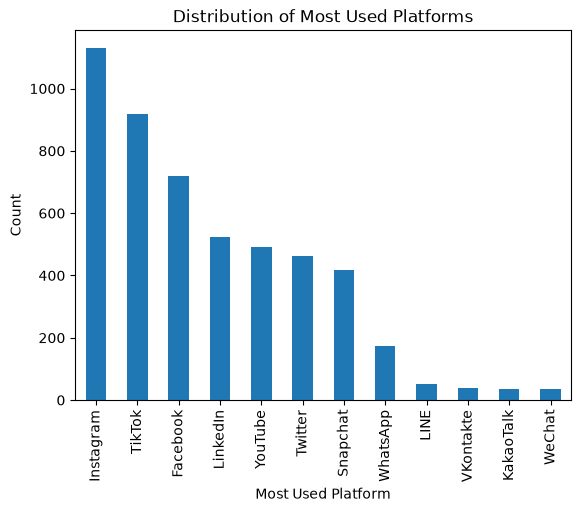

In [12]:
df.Most_Used_Platform.value_counts().plot(kind='bar')
plt.title("Distribution of Most Used Platforms")
plt.xlabel("Most Used Platform")
plt.ylabel("Count")
plt.show()

### Social Media Platform Usage by Academic Level

>This visualization compares the most used social media platforms across different academic levels.

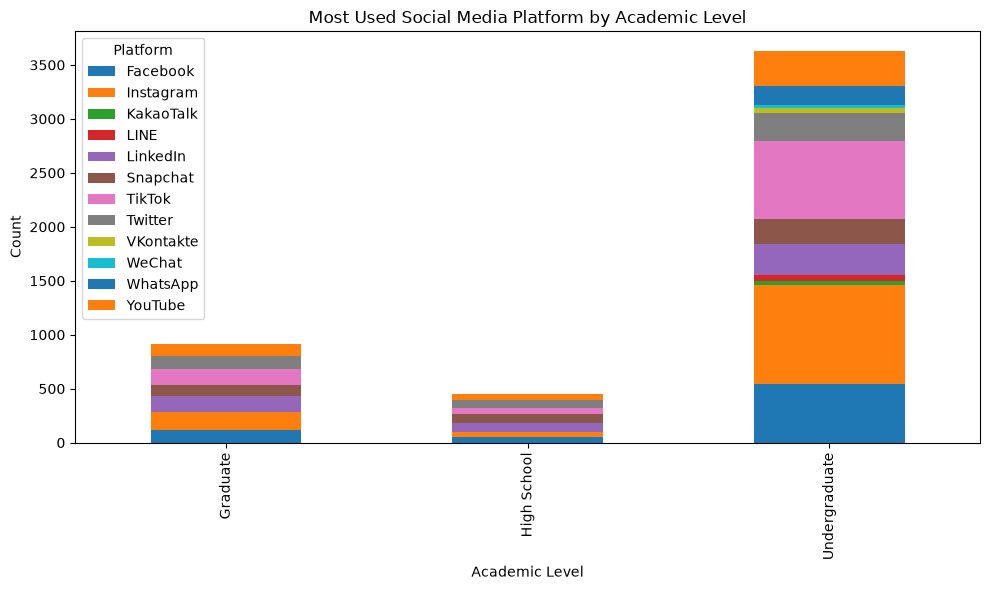

In [13]:
pd.crosstab(df['Academic_Level'], df['Most_Used_Platform']).plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Most Used Social Media Platform by Academic Level")
plt.xlabel("Academic Level")
plt.ylabel("Count")
plt.legend(title="Platform")
plt.tight_layout()
plt.show()

### Purpose of Social Media Usage

>This visualization explores the relationship between students' most used social media platforms and their purpose of using social media.

<Axes: xlabel='Most_Used_Platform'>

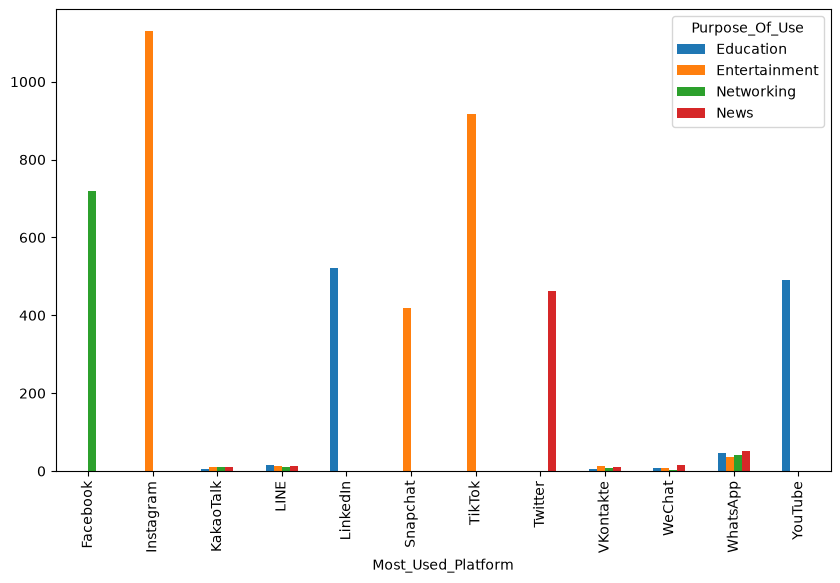

In [14]:
pd.crosstab(df.Most_Used_Platform, df.Purpose_Of_Use).plot(kind='bar', figsize=(10, 6))

### Stress Level Distribution

>The following visualization shows the distribution of students across different stress levels.

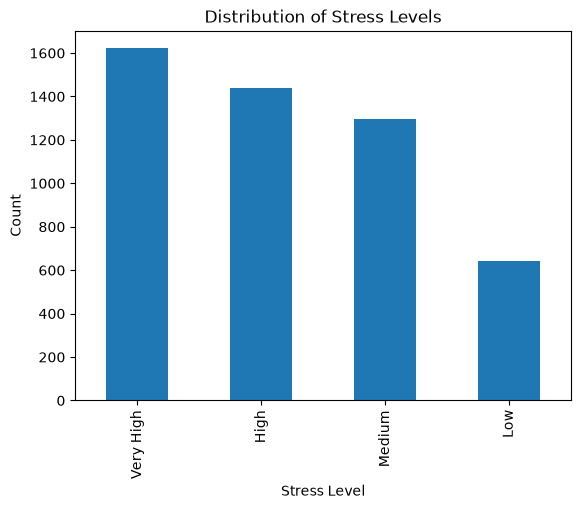

In [15]:
df.Stress_Level.value_counts().plot(kind='bar')
plt.title("Distribution of Stress Levels")
plt.xlabel("Stress Level")
plt.ylabel("Count")
plt.show()

### Mental Health Score by Stress Level

>A box plot is used to analyze how students' mental health scores vary across different stress levels.

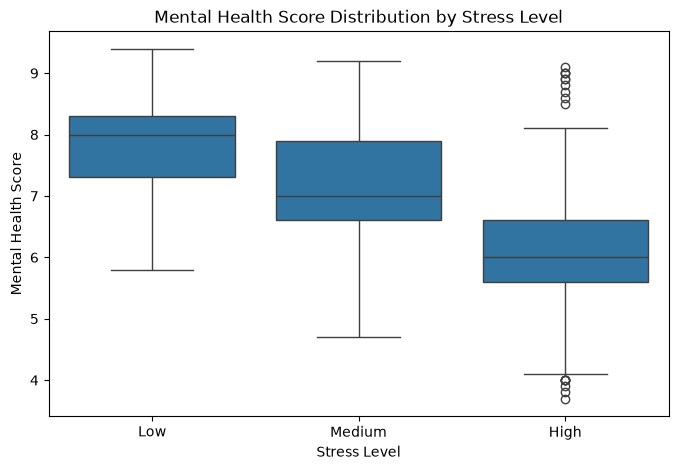

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Stress_Level', y='Mental_Health_Score', order=['Low', 'Medium', 'High'])
plt.title('Mental Health Score Distribution by Stress Level')
plt.xlabel("Stress Level")
plt.ylabel("Mental Health Score")
plt.show()

## Distribution of Numerical Features

>Histograms are used to examine the distribution of numerical variables in the dataset and identify their overall patterns.

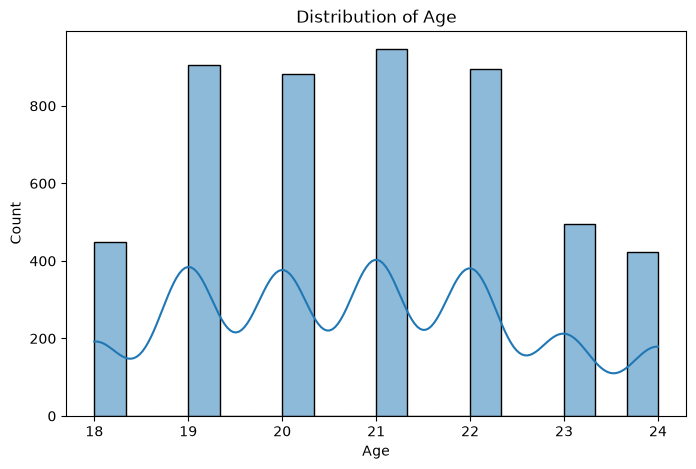

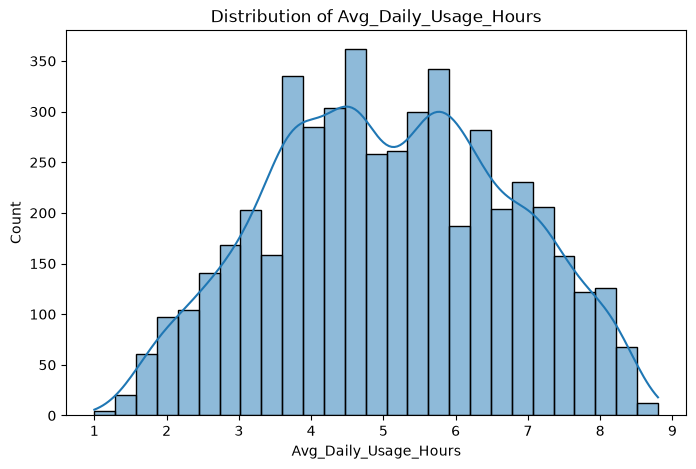

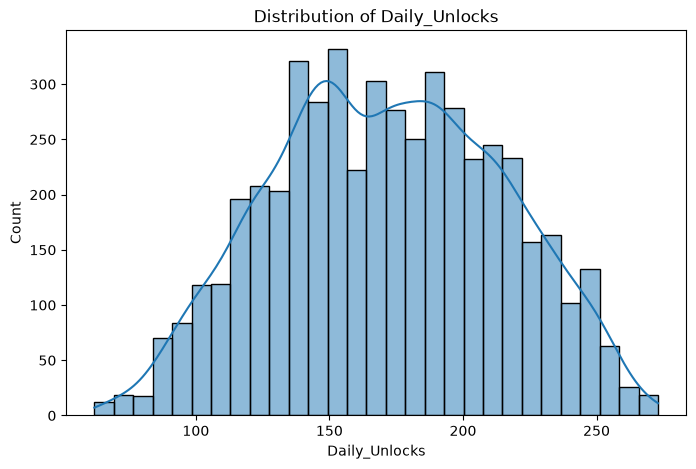

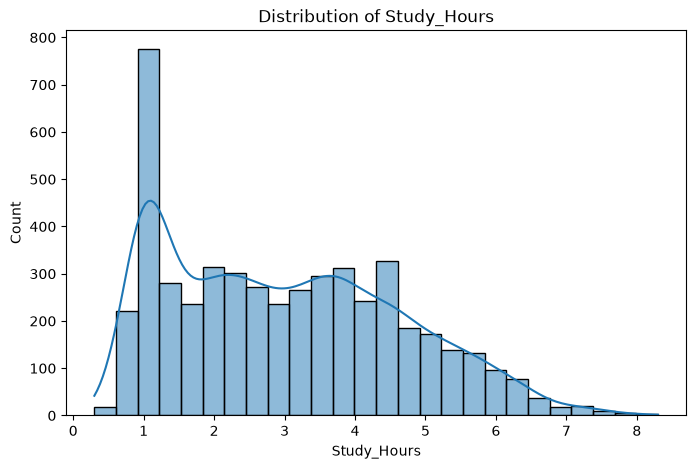

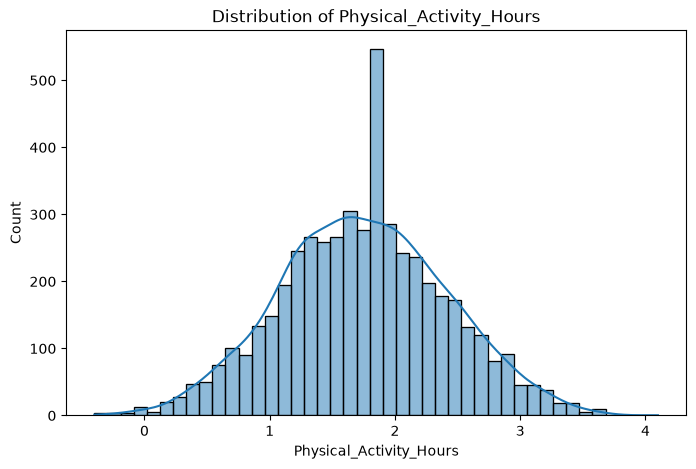

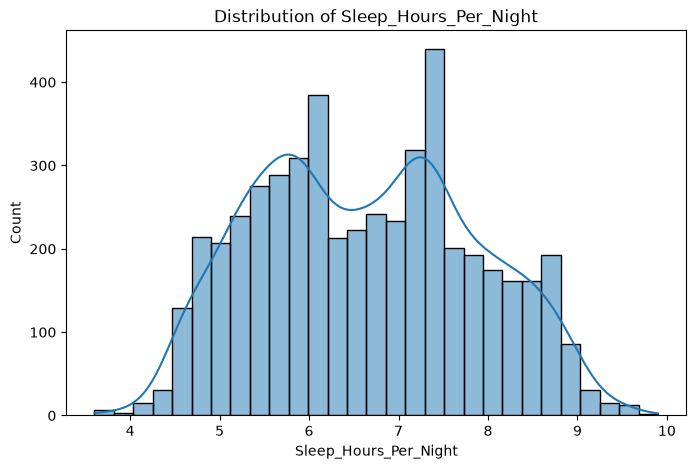

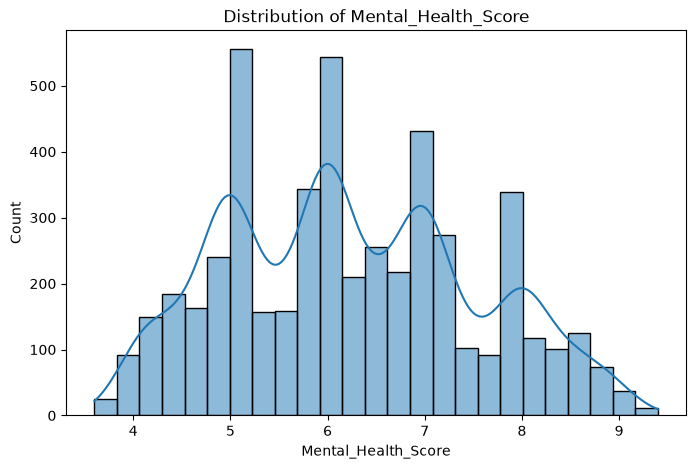

In [17]:
num_col=df.select_dtypes(include=np.number)
for col in num_col:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

## Outlier Detection

>Box plots are used to identify potential outliers and understand the spread of numerical features.

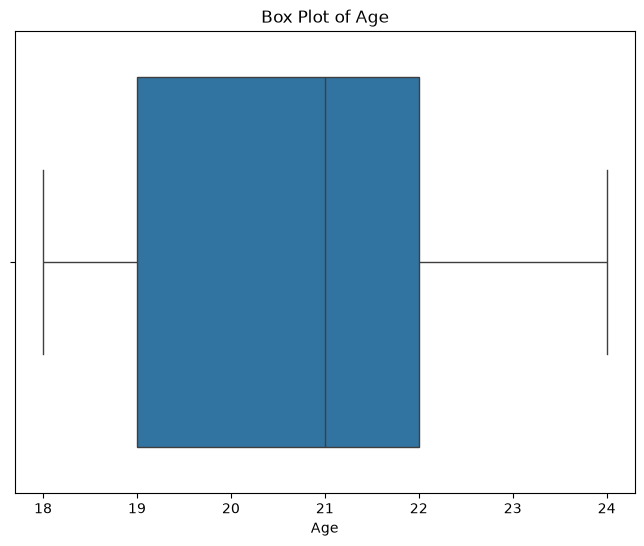

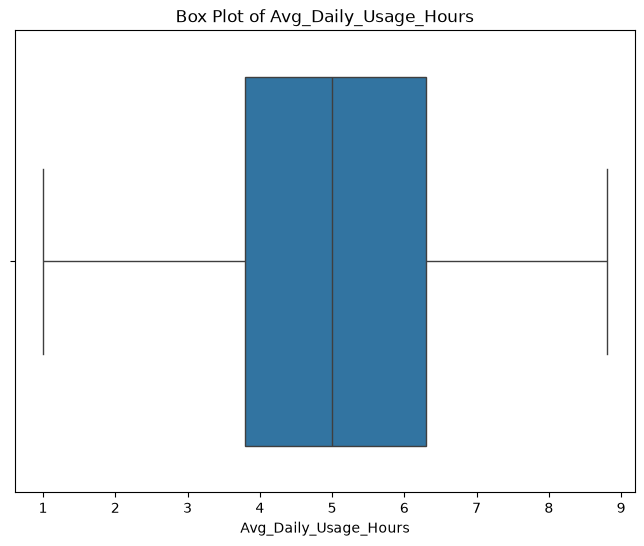

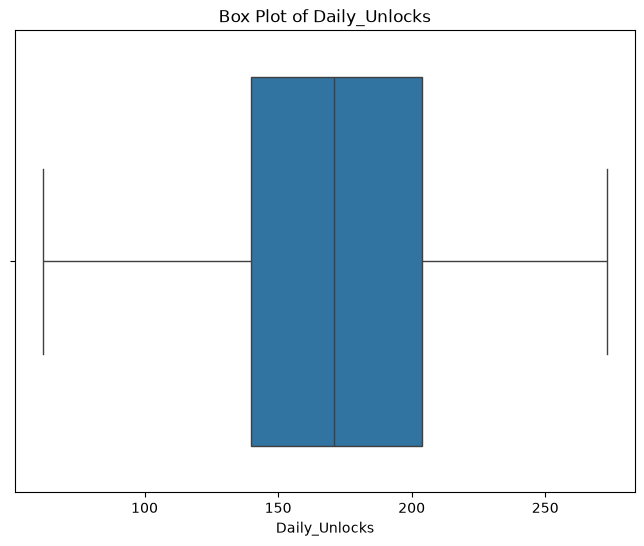

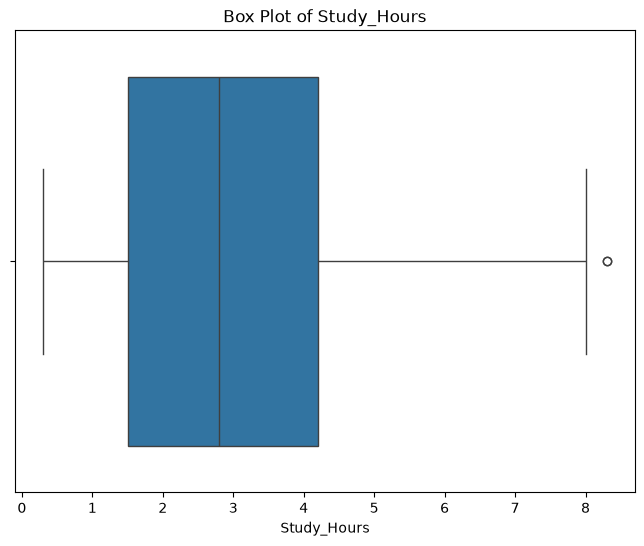

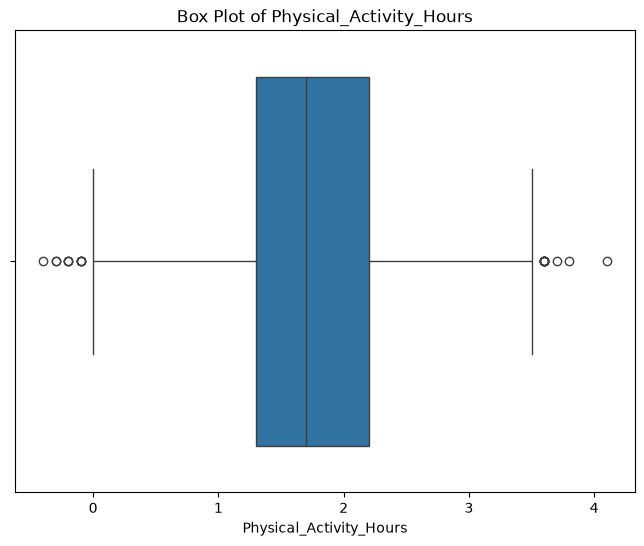

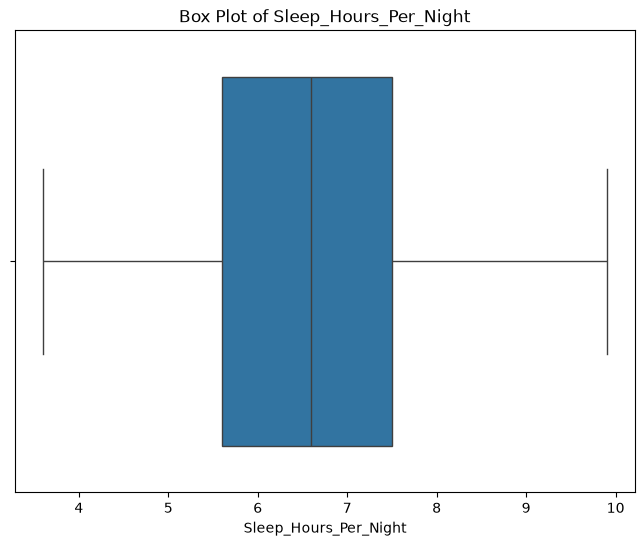

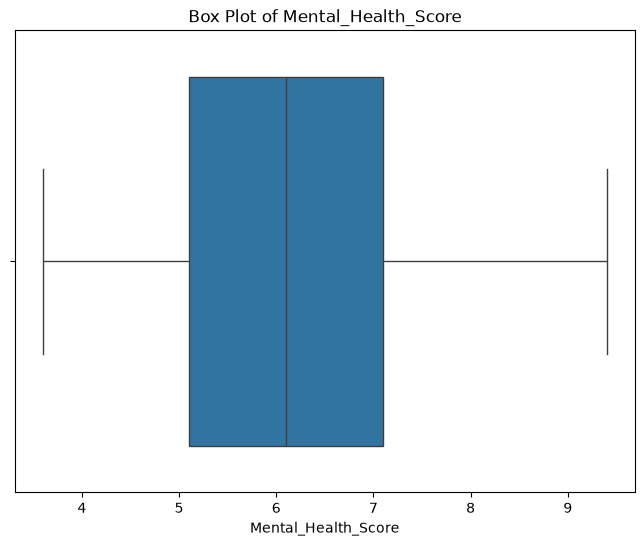

In [18]:
for col in num_col:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
    plt.show()

## Correlation Analysis

>A correlation heatmap is used to examine the relationships between numerical variables in the dataset.

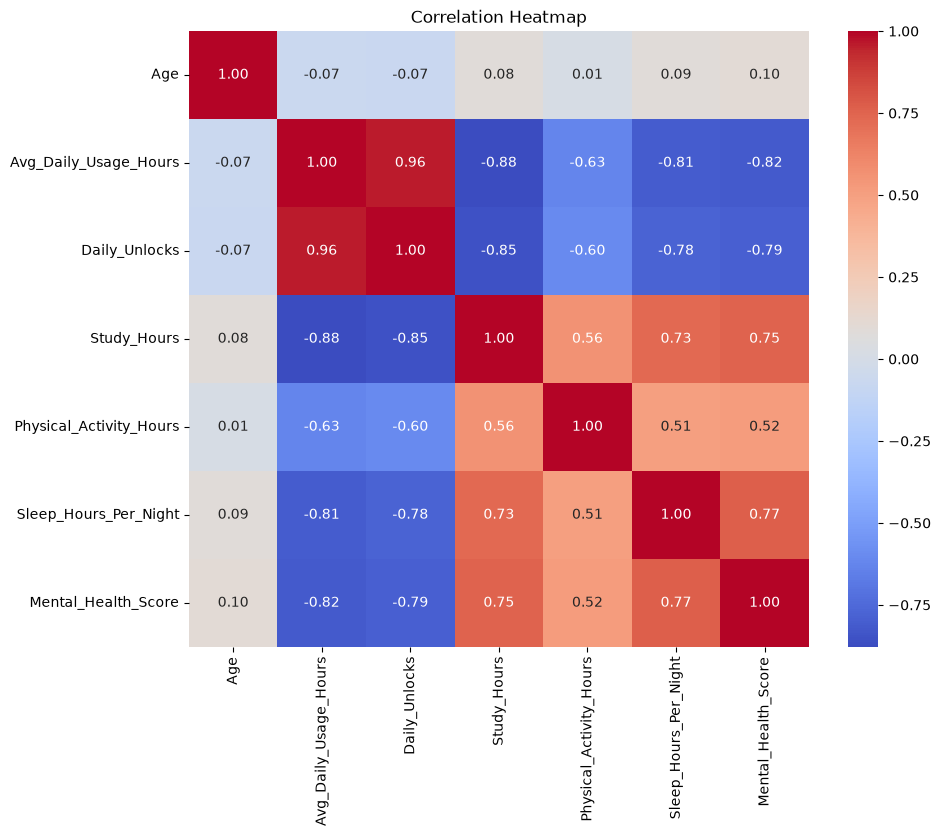

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.2f',cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Distribution of Categorical Features

>Count plots are used to visualize the frequency distribution of categorical variables in the dataset.

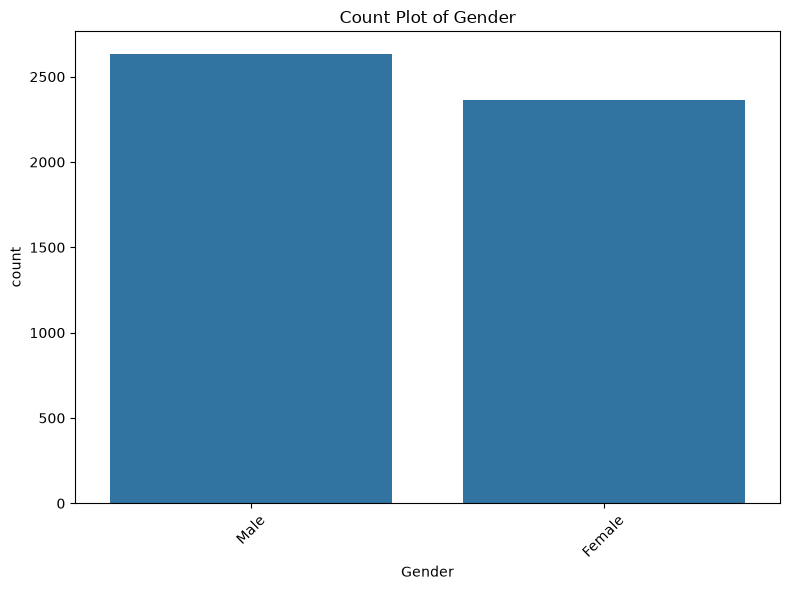

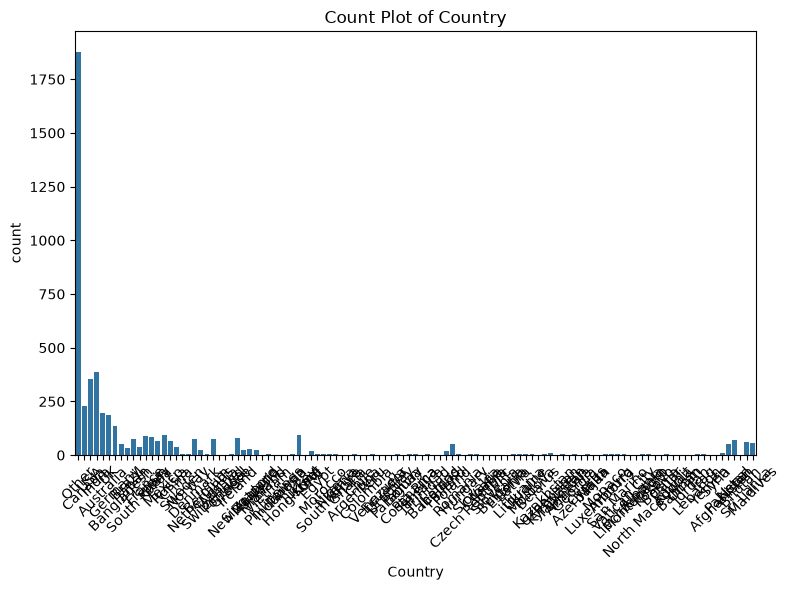

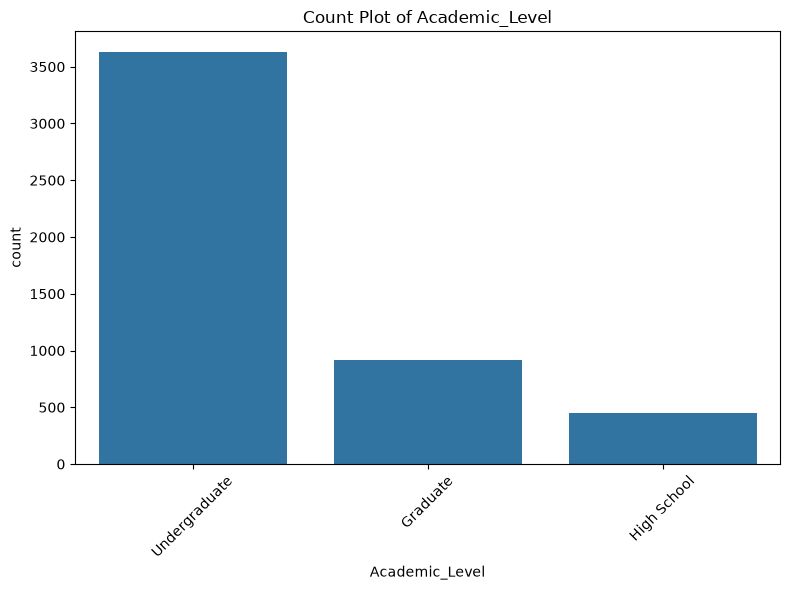

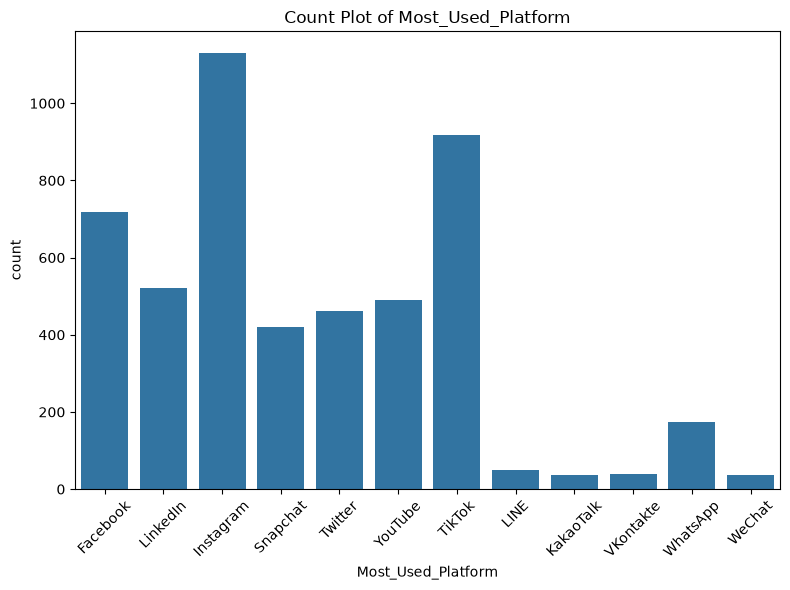

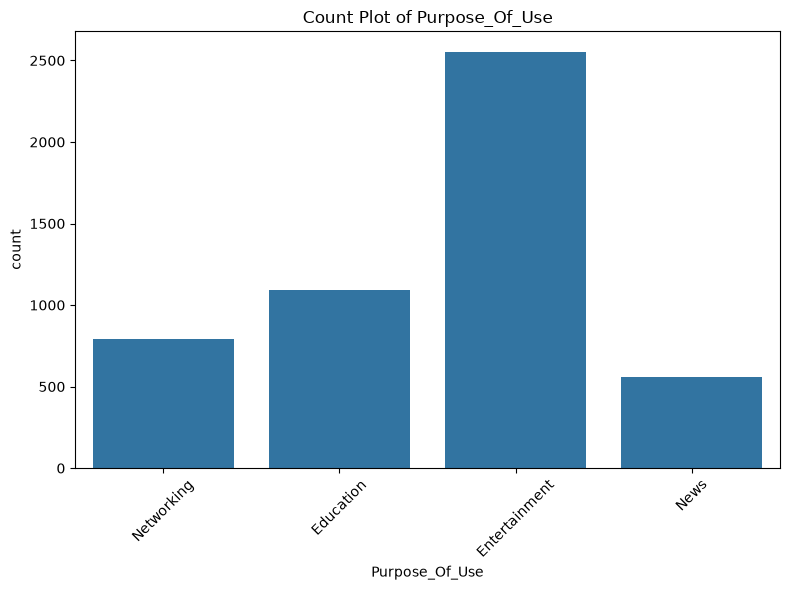

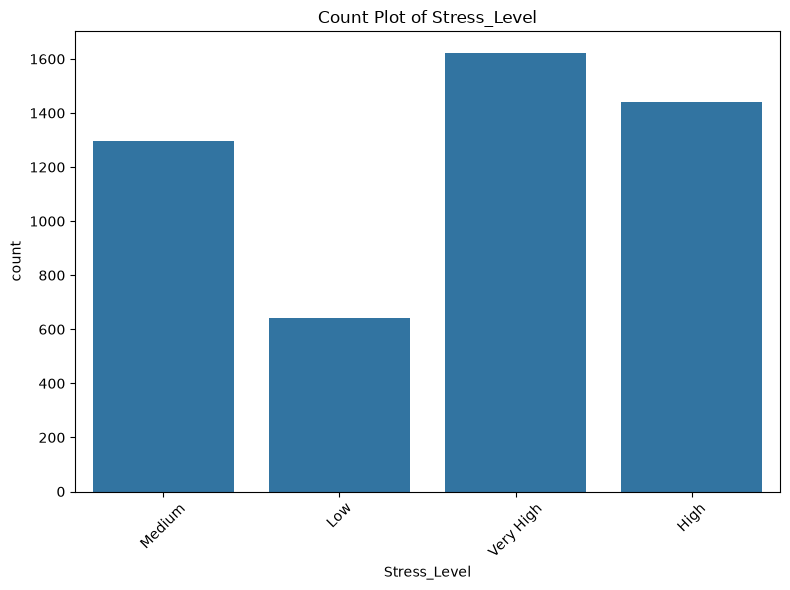

In [20]:
cat_col = df.select_dtypes(
    include=['object', 'string']
).columns

for col in cat_col:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x=col)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 6. Data Preparation and Preprocessing

>Before training machine learning models, the dataset is divided into input features and the target variable. Numerical and categorical features are then prepared for preprocessing.

### Feature and Target Selection

>>The target variable is `Mental_Health_Score`, while all remaining columns are used as input features for the machine learning models.

In [21]:
X = df.drop("Mental_Health_Score", axis=1)
y = df["Mental_Health_Score"]

## Feature Preprocessing

>Categorical features are transformed using One-Hot Encoding, while numerical features are standardized using StandardScaler. A ColumnTransformer is used to combine these preprocessing steps into a single pipeline.

In [22]:
numerical_col = X.select_dtypes(include=np.number).columns.tolist()
categorical_col = X.select_dtypes(include=["object", "string"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_col),
        ("num", StandardScaler(), numerical_col)
    ]
)

## Train-Test Split

>* The dataset is divided into training and testing sets. The training data is used to train the machine learning models, while the testing data is used to evaluate their performance.

>* A test size of 20% is used, and `random_state=42` ensures reproducible results.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Model Evaluation Function

A reusable evaluation function is created to measure the performance of regression models using the following metrics:

- **R² Score:** Measures how well the model explains the variation in the target variable.
- **MAE:** Measures the average absolute prediction error.
- **MSE:** Measures the average squared prediction error.
- **RMSE:** Measures the square root of MSE and provides an error value in the same unit as the target variable.

In [24]:
def evaluate_model(model,X_test,y_test):
    prediction = model.predict(X_test)

    return {
        "R2": r2_score(y_test,prediction),
        "MAE": mean_absolute_error(y_test,prediction),
        "MSE": mean_squared_error(y_test,prediction),
        "RMSE": np.sqrt(mean_squared_error(y_test,prediction))
    }

# 8. Actual vs Predicted Visualization

>A visualization function is created to compare the actual mental health scores with the predicted scores generated by each machine learning model.

In [25]:
def plot_actual_vs_predicted(y_true,y_pred,title):
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=y_true, y=y_pred)

    min_value= min(y_true.min(), y_pred.min())
    max_value= max(y_true.max(), y_pred.max())

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    plt.xlabel("Actual Value")
    plt.ylabel("Predicted value")
    plt.title(title)
    plt.show();

# 9. Machine Learning Model Training

* Multiple regression models are trained and evaluated to determine which model performs best for predicting students' mental health scores.

## Linear Regression (Baseline Model)

>Linear Regression is used as the baseline model. Its performance will be compared with more advanced machine learning algorithms.

In [26]:
lr_model= Pipeline([
    ("preprocessor",preprocessor),
    ('model',LinearRegression())
])
lr_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Age','Gender','Country',...,'Physical_Activity_Hours', 'Sleep_Hours_Per_Night','Stress_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throug

### Model Evaluation

>The Linear Regression model is evaluated using R², MAE, MSE, and RMSE metrics.

In [27]:
lr_metrics = evaluate_model(lr_model,X_test,y_test)
lr_metrics

{'R2': 0.7891697817508633,
 'MAE': 0.47522340611502456,
 'MSE': 0.3763758259929397,
 'RMSE': np.float64(0.6134947644380836)}

### Model Visualization

>The following plot compares the actual mental health scores with the predictions generated by the Linear Regression model.

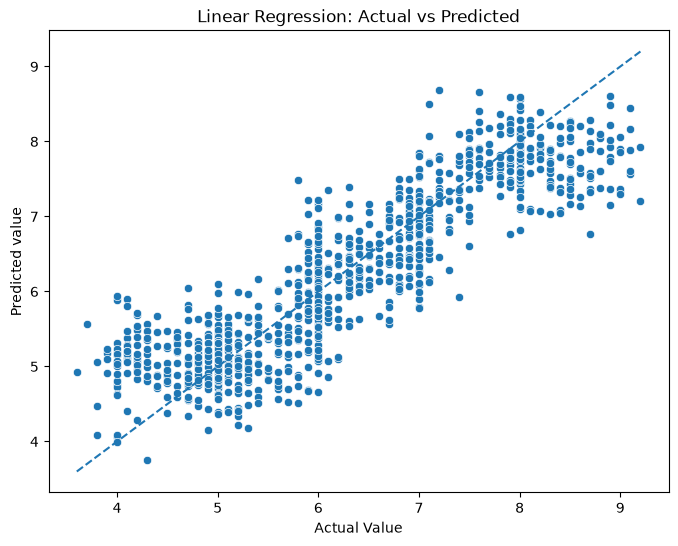

In [28]:
lr_predy = lr_model.predict(X_test)
plot_actual_vs_predicted(y_test,lr_predy,"Linear Regression: Actual vs Predicted")

## Random Forest Regressor

>Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction performance and reduce overfitting.

In [29]:
rf_model= Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestRegressor(random_state=42,
                                    n_estimators=300,
                                   min_samples_split=2,
                                   min_samples_leaf=1,
                                   max_depth=None
                                   ))
])
rf_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Age','Gender','Country',...,'Physical_Activity_Hours', 'Sleep_Hours_Per_Night','Stress_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throug

### Model Evaluation

>The Random Forest model is evaluated using training score, testing score, R², MAE, MSE, and RMSE.

In [30]:
print("Train Score:", rf_model.score(X_train, y_train))
print("Test score",rf_model.score(X_test,y_test))
rf_metrics=evaluate_model(rf_model,X_test,y_test)   
rf_metrics

Train Score: 0.9876675093457254
Test score 0.9180167330984119


{'R2': 0.9180167330984119,
 'MAE': 0.2744971444444443,
 'MSE': 0.14635719705617303,
 'RMSE': np.float64(0.3825665916623837)}

### Model Visualization

>The following visualization compares the actual mental health scores with the predictions generated by the Random Forest model.

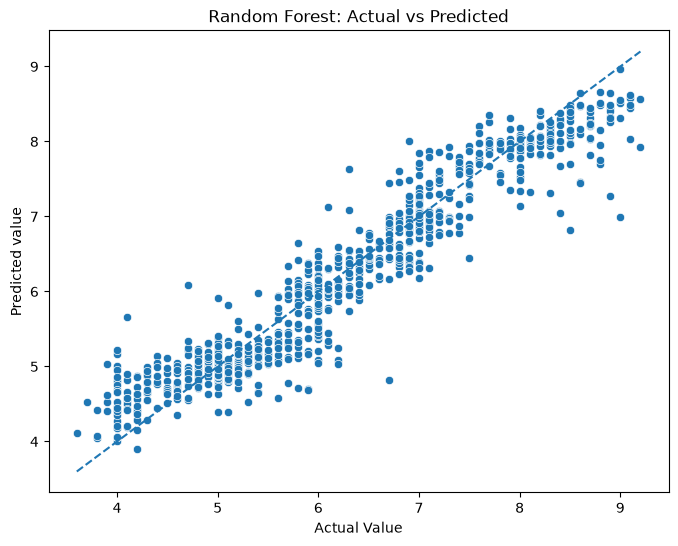

In [31]:
plot_actual_vs_predicted(y_test,rf_model.predict(X_test),"Random Forest: Actual vs Predicted")

## Gradient Boosting Regressor

>Gradient Boosting is an ensemble learning algorithm that builds models sequentially, with each new model attempting to improve the errors made by previous models.

In [32]:
gbr_model= Pipeline([
    ("preprocessor",preprocessor),
    ("model",GradientBoostingRegressor(random_state=42,
                                        n_estimators=300,
                                        learning_rate=0.1,
                                        max_depth=3
                                        ))
])
gbr_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Age','Gender','Country',...,'Physical_Activity_Hours', 'Sleep_Hours_Per_Night','Stress_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throug

### Model Evaluation

>The Gradient Boosting model is evaluated using training score, testing score, R², MAE, MSE, and RMSE.

In [33]:
print("Train Score:", gbr_model.score(X_train, y_train))
print("Test Score:", gbr_model.score(X_test, y_test))

gbr_metrics=evaluate_model(gbr_model,X_test,y_test)
gbr_metrics

Train Score: 0.8811072667744954
Test Score: 0.8626539550163635


{'R2': 0.8626539550163635,
 'MAE': 0.3768298538578691,
 'MSE': 0.24519128024851491,
 'RMSE': np.float64(0.4951679313611847)}

### Model Visualization

>The following visualization compares the actual mental health scores with the predictions generated by the Gradient Boosting model.

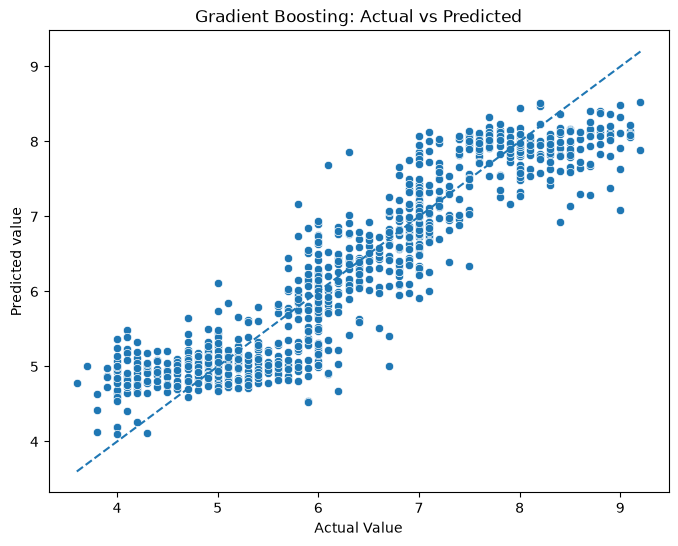

In [34]:
plot_actual_vs_predicted(y_test,gbr_model.predict(X_test),"Gradient Boosting: Actual vs Predicted")

# XGBoost Regressor

In [35]:
xgb_model= Pipeline([
    ("preprocessor",preprocessor),
    ("model",XGBRegressor(random_state=42
                          ))
])
xgb_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Age','Gender','Country',...,'Physical_Activity_Hours', 'Sleep_Hours_Per_Night','Stress_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throug

## XGBoost Regressor

>XGBoost is a powerful gradient boosting algorithm that is widely used for machine learning regression and prediction tasks.

In [36]:
print("Train Score:", xgb_model.score(X_train, y_train))
print("Test Score:", xgb_model.score(X_test, y_test))

xgb_metrics=evaluate_model(xgb_model,X_test,y_test)
xgb_metrics

Train Score: 0.9656873597917197
Test Score: 0.9017968737757001


{'R2': 0.9017968737757001,
 'MAE': 0.30663650350570676,
 'MSE': 0.17531302227313017,
 'RMSE': np.float64(0.41870397928982017)}

### Model Evaluation

>The XGBoost model is evaluated using training score, testing score, R², MAE, MSE, and RMSE.

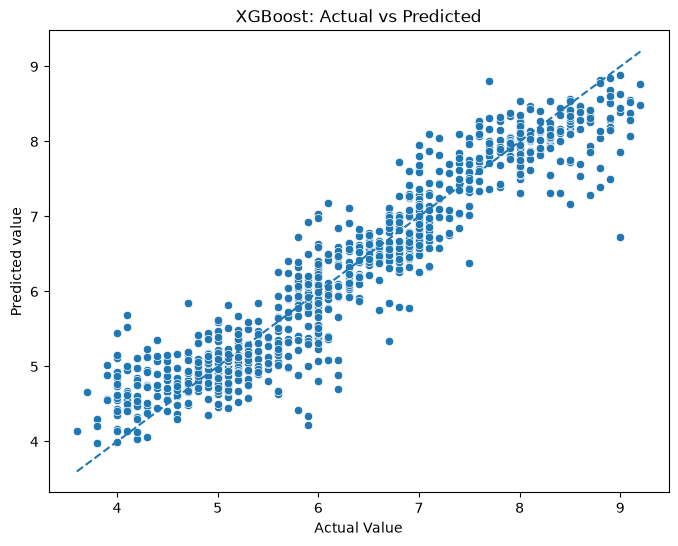

In [37]:
plot_actual_vs_predicted(y_test,xgb_model.predict(X_test),"XGBoost: Actual vs Predicted")

# 10. Model Comparison

>The performance of all trained machine learning models is compared using regression evaluation metrics. The model with the best overall performance will be selected as the final model.

In [38]:
results={
    "Linear Regression": evaluate_model(lr_model,X_test,y_test),
    "Random Forest": evaluate_model(rf_model,X_test,y_test),
    "Gradient Boosting": evaluate_model(gbr_model,X_test,y_test),
    "XGBoost": evaluate_model(xgb_model,X_test,y_test)
}
model_comparison=pd.DataFrame(results).T
model_comparison

,R2,MAE,MSE,RMSE
Linear Regression,0.789170,0.475223,0.376376,0.613495
Random Forest,0.918017,0.274497,0.146357,0.382567
Gradient Boosting,0.862654,0.376830,0.245191,0.495168
XGBoost,0.901797,0.306637,0.175313,0.418704


## Model Performance Comparison

>The following visualization compares the performance of the trained models based on their evaluation metrics.

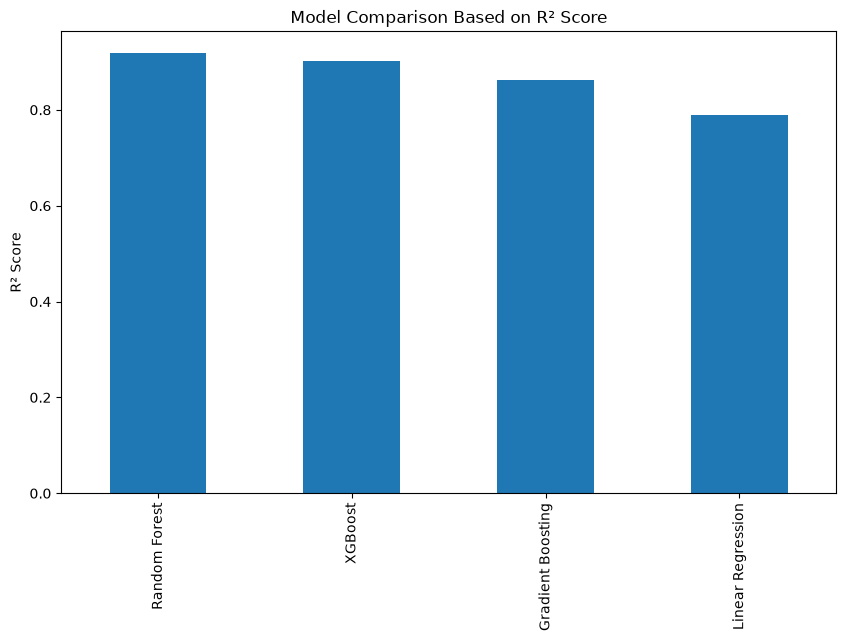

In [39]:
model_comparison.sort_values(
    by="R2",
    ascending=False
)["R2"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Comparison Based on R² Score")
plt.ylabel("R² Score")
plt.show()

# 11-Model Selection
>Based on the evaluation results, Random Forest was selected as the final model because it demonstrated the best overall performance among the tested models.

In [40]:
final_model= Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestRegressor(random_state=42,
                                    n_estimators=300,
                                   min_samples_split=2,
                                   min_samples_leaf=1,
                                   max_depth=None
                                   ))
])
final_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Age','Gender','Country',...,'Physical_Activity_Hours', 'Sleep_Hours_Per_Night','Stress_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throug

## Final Model Evaluation

>The selected final model is evaluated on the test dataset to measure its ability to predict unseen student mental health scores.

In [41]:
final_model_evaluation=evaluate_model(final_model,X_test,y_test)
final_model_evaluation

{'R2': 0.9180167330984119,
 'MAE': 0.2744971444444443,
 'MSE': 0.14635719705617303,
 'RMSE': np.float64(0.3825665916623837)}

## Final Model Visualization

>The following plot compares the actual values with the predictions generated by the final selected model.

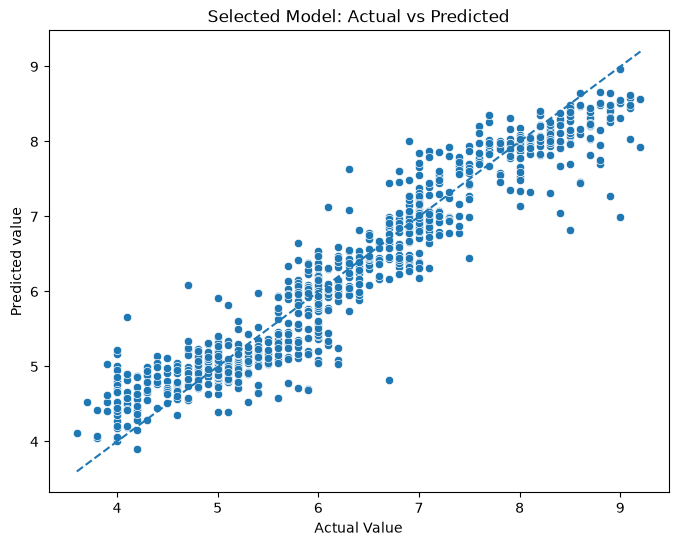

In [42]:
plot_actual_vs_predicted(y_test,rf_model.predict(X_test),"Selected Model: Actual vs Predicted")

## Feature Importance Analysis

>* Feature importance analysis is performed to identify which input features have the greatest influence on the predictions made by the Random Forest model.

>* This analysis helps improve the interpretability of the machine learning model and provides insights into the factors that are most important for predicting students' mental health scores.

In [43]:
# Get feature names from preprocessor
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

# Get the Random Forest model from pipeline
final_model = final_model.named_steps["model"]

# Get feature importances
importances = final_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
129,num__Avg_Daily_Usage_Hours,0.683606
133,num__Sleep_Hours_Per_Night,0.097015
130,num__Daily_Unlocks,0.027014
132,num__Physical_Activity_Hours,0.017425
131,num__Study_Hours,0.016944
70,cat__Country_Pakistan,0.016268
12,cat__Country_Bangladesh,0.012670
128,num__Age,0.010578
87,cat__Country_Spain,0.009302
69,cat__Country_Other,0.009243


### Top 10 Important Features

>The following visualization displays the ten most important features according to the Random Forest model.

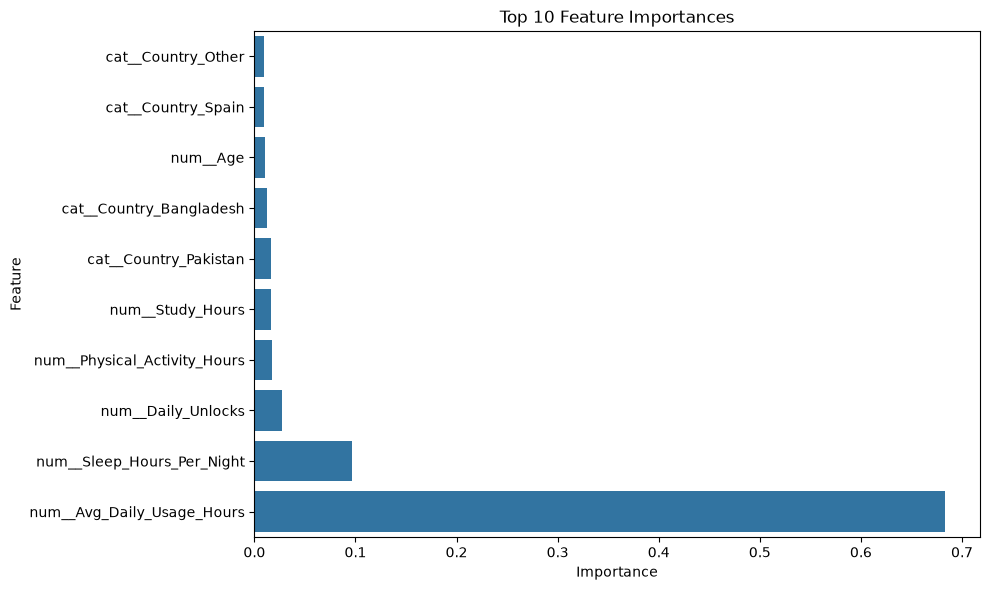

In [44]:
top_features = feature_importance_df.head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

# 12. Saving the Final Model

>The selected machine learning pipeline, including preprocessing and the trained model, is saved using Joblib. This allows the model to be reused later for predictions without retraining.

In [45]:
import joblib
joblib.dump(final_model, "Random_ForestRegression_model.pkl")

['Random_ForestRegression_model.pkl']

# 13. Conclusion

In this project, multiple machine learning regression models were developed to predict students' mental health scores based on social media usage and other relevant factors.

The project included:

- Data loading and exploration
- Data cleaning
- Exploratory Data Analysis
- Feature preprocessing
- Training multiple regression models
- Model evaluation and comparison
- Final model selection
- Feature importance analysis
- Saving the trained model

The final selected model can be used to predict students' mental health scores based on new input data. Future improvements may include hyperparameter tuning, additional feature engineering, and testing the model on larger datasets.